In [8]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
print("LangGraph OK")

LangGraph OK


In [2]:
class StateGraphData(TypedDict):
    a: int
    b: int
    c: int
    equation: str
    discriminant: float
    answer: str

In [3]:
def show_eq(state: StateGraphData):
    eq=f"{state['a']}x^2 + {state['b']}x + {state['c']} = 0"
    return {'equation': eq}


In [4]:
def calculate_discriminant(state: StateGraphData):
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = b**2 - 4*a*c
    return {'discriminant': discriminant}

In [5]:
def no_real_solutions(state: StateGraphData):
    return {'answer': "No real solutions"}

In [6]:
def repeated_solutions(state: StateGraphData):
    a = state['a']
    b = state['b']
    c = state['c']
    root = -b / (2*a)
    return {'answer': f"Repeated solution: x = {root}"}

In [7]:
def real_solutions(state: StateGraphData):
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = state['discriminant']
    root1 = (-b + discriminant**0.5) / (2*a)
    root2 = (-b - discriminant**0.5) / (2*a)
    return {'answer': f"Two real solutions: x1 = {root1}, x2 = {root2}"}

In [9]:
def check_conditions(state: StateGraphData) -> Literal['no_real_solutions', 'repeated_solutions', 'real_solutions']: #this function checks the discriminant and returns the appropriate next node's name
    discriminant = state['discriminant']
    if discriminant < 0:
        return 'no_real_solutions'
    elif discriminant == 0:
        return 'repeated_solutions'
    else:
        return 'real_solutions'

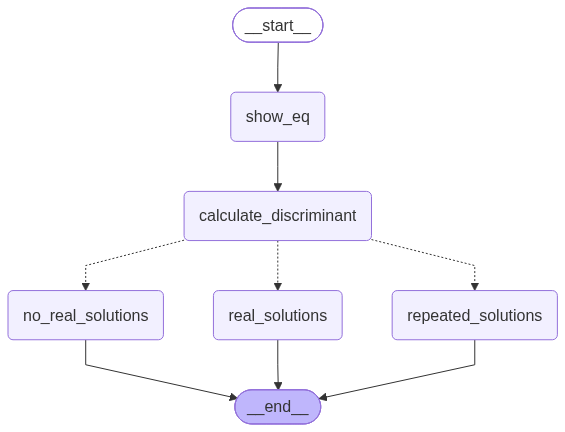

In [10]:
graph = StateGraph(StateGraphData)

graph.add_node('show_eq',show_eq)
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('no_real_solutions',no_real_solutions)
graph.add_node('real_solutions',real_solutions)
graph.add_node('repeated_solutions',repeated_solutions)

graph.add_edge(START, 'show_eq')
graph.add_edge('show_eq', 'calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant', check_conditions)
graph.add_edge('no_real_solutions', END)
graph.add_edge('repeated_solutions', END)
graph.add_edge('real_solutions', END)

workflow= graph.compile()
workflow

In [15]:
initial_state = {
    'a': 1,
    'b': -3,
    'c': 9,
}
ans= workflow.invoke(initial_state)
print(ans)

{'a': 1, 'b': -3, 'c': 9, 'equation': '1x^2 + -3x + 9 = 0', 'discriminant': -27, 'answer': 'No real solutions'}
